In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import ensemble
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn import metrics
import math

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path='/content/drive/MyDrive/insurance.csv'
df=pd.read_csv(file_path)
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df['smoker']=le.fit_transform(df['smoker'])
df['region']=le.fit_transform(df['region'])

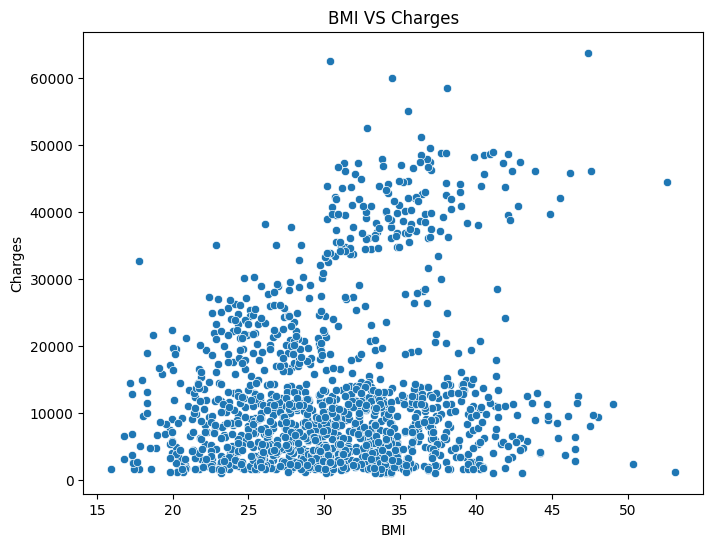

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x=df['bmi'],y=df['charges'])
plt.title('BMI VS Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

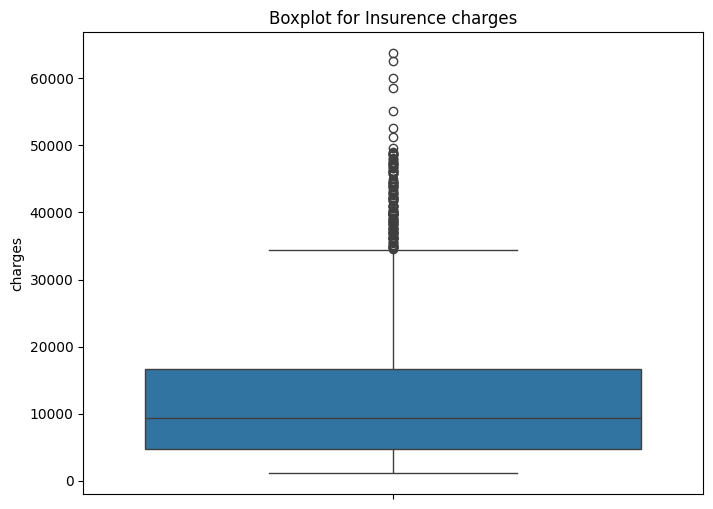

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df['charges'] )
plt.title('Boxplot for Insurence charges')
plt.show()

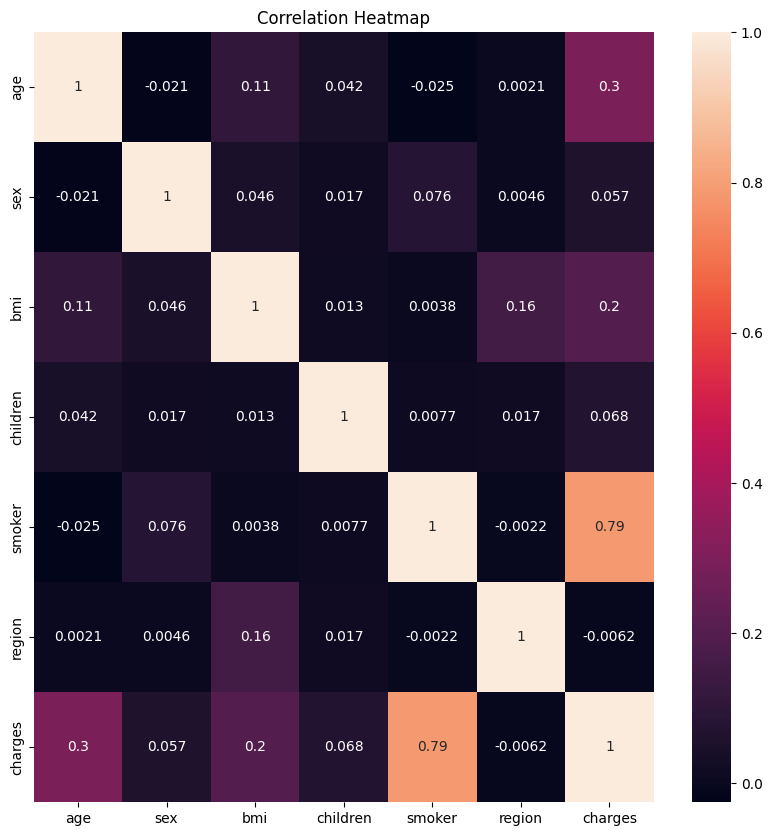

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
x=df.drop('charges',axis=1)
y=df['charges']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

rf=ensemble.RandomForestRegressor(random_state=0)
rf.fit(x_train,y_train)

lr=LinearRegression()
lr.fit(x_train,y_train)

rf=DecisionTreeRegressor()
rf.fit(x_train,y_train)

ab=AdaBoostRegressor()
ab.fit(x_train,y_train)

AdaBoostRegressor()

In [ ]:
y_pred=rf.predict(x_test)
y_pred
y_pred_lr=lr.predict(x_test)
y_pred_lr
y_pred_dt=rf.predict(x_test)
y_pred_dt
y_pred_ab=ab.predict(x_test)
y_pred_ab

array([11293.37086737,  6561.01906588, 24873.63138321, 11293.37086737,
       36287.38397429,  6561.01906588,  5942.78171507, 16755.29416869,
        6561.01906588, 12993.85447812, 18514.47525032,  9882.72805324,
        9882.72805324, 44596.21493204, 44596.21493204, 44596.21493204,
       12993.85447812, 44596.21493204, 11293.37086737, 24873.63138321,
        6561.01906588, 11293.37086737,  5397.10860202,  5942.78171507,
       12993.85447812, 16755.29416869, 16755.29416869,  9882.72805324,
       12993.85447812,  5942.78171507,  6561.01906588, 16755.29416869,
        5942.78171507,  9882.72805324,  6561.01906588, 11293.37086737,
        5397.10860202, 11293.37086737, 24873.63138321, 44596.21493204,
        5397.10860202,  9882.72805324, 16755.29416869, 16755.29416869,
        9882.72805324, 16755.29416869,  9882.72805324,  6561.01906588,
       44596.21493204,  9882.72805324, 16755.29416869,  9882.72805324,
        9882.72805324,  5942.78171507, 16755.29416869, 12993.85447812,
      

Random Forest 0.7135604354272376
Logitistic Regression 0.7833463107364537
Decision Tree 0.7135604354272376
AdaBoost -0.06821813183902203


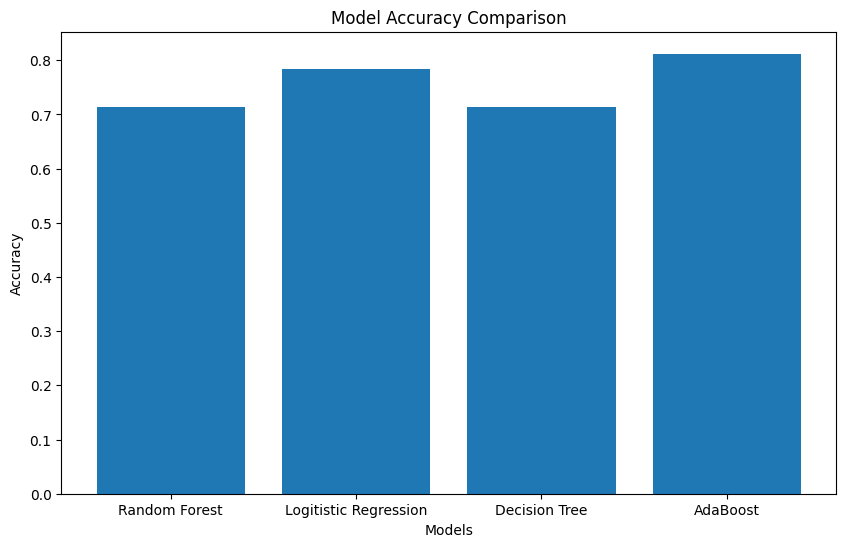

Best Model: AdaBoost


In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print('Random Forest', r2_score(y_test, y_pred))
print('Logitistic Regression', r2_score(y_test, y_pred_lr))
print('Decision Tree', r2_score(y_test, y_pred_dt))
print('AdaBoost', r2_score(y_test, y_pred_knn))
model_accuracy = {
    'Random Forest': r2_score(y_test, y_pred),
    'Logitistic Regression': r2_score(y_test, y_pred_lr),
    'Decision Tree': r2_score(y_test, y_pred_dt),
    'AdaBoost': r2_score(y_test, y_pred_ab)
}
plt.figure(figsize=(10,6))
plt.bar(model_accuracy.keys(), model_accuracy.values())
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()
best_model = max(model_accuracy, key=model_accuracy.get)
print("Best Model:", best_model)

In [ ]:
def predict_outcome():
  featuress=[]
  for col in x.columns:
    value=float(input(f"Enter the value for {col}: "))
    featuress.append(value)

  featuress=np.array(featuress).reshape(1,-1)
  prediction=rf.predict(featuress)

  print("Predicted Insurance Charges:", prediction[0])

In [ ]:
predict_outcome()

Enter the value for age: 19
Enter the value for sex: 0
Enter the value for bmi: 27.9
Enter the value for children: 0
Enter the value for smoker: 1
Enter the value for region: 3
Predicted Insurance Charges: 48173.361
